In [ ]:
!pip install -q scikit-learn scipy seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
uploaded = files.upload()

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv


In [4]:
file_name = "placement_predict_50k Dataset.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 50000
Number of columns: 32

Column names:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              50000 non-null

In [6]:
print("Missing values:")
missing = df.isnull().sum()
display(missing[missing > 0])

Missing values:


,0
Workshops,4488
AptitudeTestScore,4029
SoftSkillsRating,3526
CodingTestScore,2976
MockInterviewScore,4957


In [7]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (50000, 32)


## Feature Selection

For clustering, we want to group students using their characteristics.



In [8]:

drop_columns = [
    "StudentID",
    "Salary Package",
    "IsAnomaly",
    "PlacementStatus"
]

drop_columns = [col for col in drop_columns if col in df.columns]

X = df.drop(columns=drop_columns)

print("Removed columns:", drop_columns)
print("Clustering feature shape:", X.shape)

Removed columns: ['StudentID', 'Salary Package', 'IsAnomaly', 'PlacementStatus']
Clustering feature shape: (50000, 28)


In [9]:
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numeric_columns)

Categorical columns:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']

Numerical columns:
['SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular']


In [10]:
# Encode categorical features
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape after encoding:", X.shape)
display(X.head())

Shape after encoding: (50000, 44)


,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,AttendancePercent,...,Stream_EE,Stream_IT,Stream_Mechanical,Specialisation_DataScience,Specialisation_Embedded,Specialisation_Networking,Hostel_Yes,HistoryOfBacklogs_Yes,CGPA_Tier_Low,CGPA_Tier_Mid
0,6.02,6.54,6.52,6.00,6.47,5.91,6.49,5.50,6.29,73.3,...,False,False,False,False,False,True,False,False,True,False
1,5.84,5.12,5.34,5.18,5.03,4.93,5.40,5.13,5.23,54.5,...,False,False,False,True,False,False,True,True,True,False
2,4.91,5.29,5.49,5.73,5.33,5.88,5.82,5.67,5.52,77.6,...,False,True,False,True,False,False,True,False,True,False
3,7.67,8.03,8.08,7.64,6.86,7.10,7.56,7.39,7.51,68.8,...,False,False,False,False,False,False,False,False,False,True
4,8.14,8.97,8.36,8.55,8.55,8.38,9.10,8.86,8.65,95.8,...,False,True,False,True,False,False,True,False,False,False


In [11]:
# Handle missing values
X = X.fillna(X.median(numeric_only=True))

# Safety check for any remaining missing values
if X.isnull().sum().sum() > 0:
    X = X.fillna(0)

print("Remaining missing values:", X.isnull().sum().sum())

Remaining missing values: 0


## Feature Scaling

Clustering algorithms are distance-based. Therefore, features with larger numerical ranges can dominate the distance calculation.

StandardScaler transforms features approximately to:

- Mean = 0
- Standard deviation = 1

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (50000, 44)


# 1. K-Means Clustering

K-Means divides the data into K clusters.

We first use the Elbow Method to select a suitable value of K.

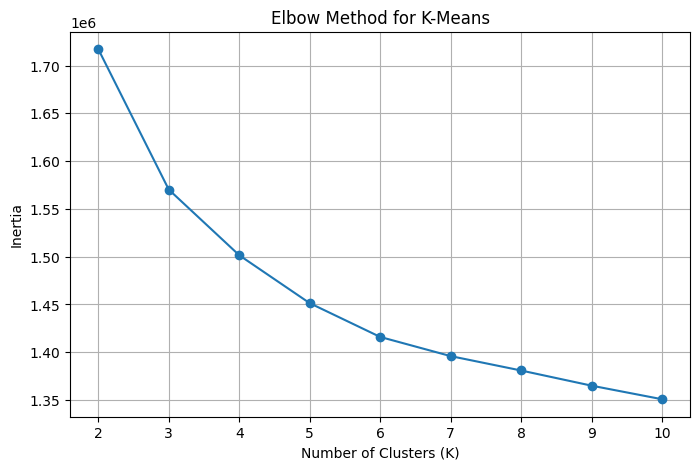

In [13]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

### Silhouette Score

The silhouette score measures how well-separated the clusters are.

Higher values generally indicate better-defined clusters.

In [14]:
silhouette_scores = []

# Silhouette score is O(N^2) complexity. We use a sample of 10,000 rows to calculate it efficiently.
sil_sample_size = min(10000, len(X_scaled))
rng_sil = np.random.RandomState(42)
sil_indices = rng_sil.choice(
    len(X_scaled),
    size=sil_sample_size,
    replace=False
)

X_scaled_sil_sample = X_scaled[sil_indices]

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    # Fit on all data but predict on the sample for silhouette evaluation
    kmeans.fit(X_scaled)
    labels_sample = kmeans.predict(X_scaled_sil_sample)
    score = silhouette_score(X_scaled_sil_sample, labels_sample)
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_scores
})

display(silhouette_results)

,K,Silhouette Score
0,2,0.191536
1,3,0.120829
2,4,0.104918
3,5,0.094934
4,6,0.091921
5,7,0.086466
6,8,0.080391
7,9,0.078843
8,10,0.064440


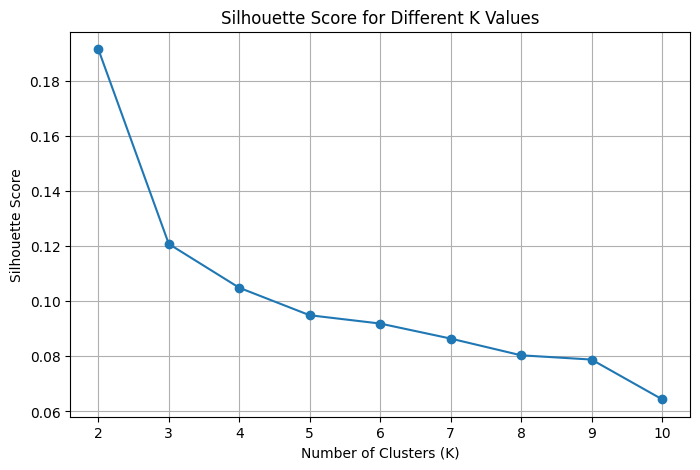

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_results["K"],
    silhouette_results["Silhouette Score"],
    marker="o"
)
plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [16]:
# Select K using the highest silhouette score
best_k = int(
    silhouette_results.loc[
        silhouette_results["Silhouette Score"].idxmax(),
        "K"
    ]
)

print("Best K based on silhouette score:", best_k)

Best K based on silhouette score: 2


In [17]:
kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(X_scaled)

print("K-Means clustering completed!")
print("Cluster counts:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means clustering completed!
Cluster counts:
0    30278
1    19722
Name: count, dtype: int64


In [18]:
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("K-Means Silhouette Score:", round(kmeans_silhouette, 4))

K-Means Silhouette Score: 0.1914


### K-Means Cluster Visualization

Because the dataset can contain many dimensions, PCA is used only for visualization. It does not replace the original clustering features.

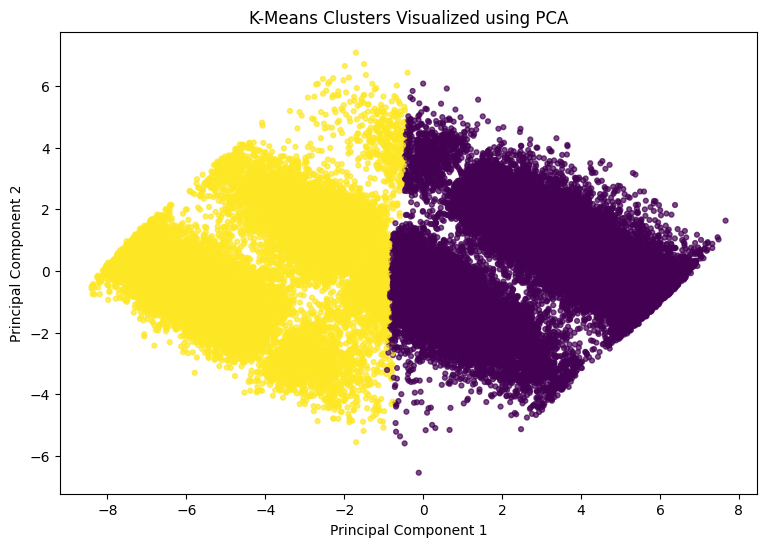

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=12,
    alpha=0.7
)

plt.title("K-Means Clusters Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# 2. Hierarchical Agglomerative Clustering

Agglomerative clustering starts with individual observations and repeatedly merges the closest clusters.

A dendrogram helps visualize the hierarchy.

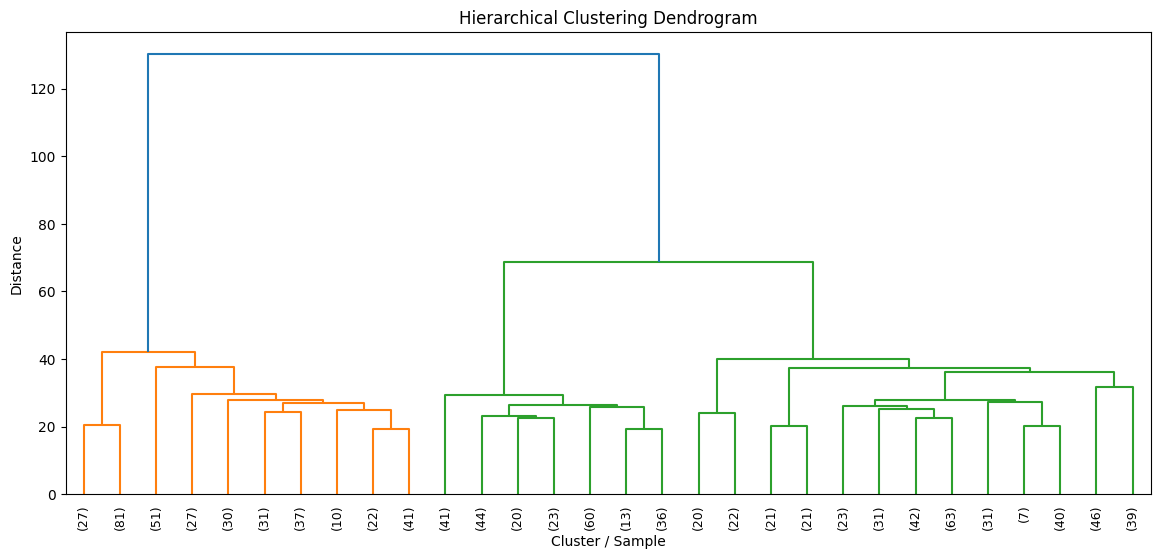

In [20]:
# Use a sample for the dendrogram so the visualization remains readable
sample_size = min(1000, len(X_scaled))
rng = np.random.RandomState(42)
sample_indices = rng.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_hier_sample = X_scaled[sample_indices]

linkage_matrix = linkage(
    X_hier_sample,
    method="ward"
)

plt.figure(figsize=(14, 6))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster / Sample")
plt.ylabel("Distance")
plt.show()

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# 1. Load the dataset (to handle cleared session variables)
try:
    df = pd.read_csv("placement_predict_50k Dataset.csv")
except FileNotFoundError:
    raise FileNotFoundError("Please make sure 'placement_predict_50k Dataset.csv' is uploaded to the root directory.")

# 2. Select and clean features
drop_columns = ["StudentID", "Salary Package", "IsAnomaly", "PlacementStatus"]
drop_columns = [col for col in drop_columns if col in df.columns]
X = df.drop(columns=drop_columns)

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)
X = X.fillna(X.median(numeric_only=True))
if X.isnull().sum().sum() > 0:
    X = X.fillna(0)

# 3. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Set best_k based on optimal silhouette evaluation (best_k = 2)
best_k = 2

# 5. Run Hierarchical clustering on a representative sample of 10,000 rows
hier_sample_size = min(10000, len(X_scaled))
rng_hier = np.random.RandomState(42)
hier_indices = rng_hier.choice(
    len(X_scaled),
    size=hier_sample_size,
    replace=False
)

X_scaled_hier_sample = X_scaled[hier_indices]

hierarchical_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hier_sample_labels = hierarchical_model.fit_predict(X_scaled_hier_sample)

hierarchical_labels = np.full(len(X_scaled), -1)
hierarchical_labels[hier_indices] = hier_sample_labels

print("Hierarchical clustering completed on sample successfully!")
print("Cluster counts on sample:")
print(pd.Series(hier_sample_labels).value_counts().sort_index())

Hierarchical clustering completed on sample successfully!
Cluster counts on sample:
0    6755
1    3245
Name: count, dtype: int64


In [22]:
import numpy as np
from sklearn.metrics import silhouette_score

# Calculate silhouette score only on the sampled non-placeholder labels
hier_sample_mask = hierarchical_labels != -1
hierarchical_silhouette = silhouette_score(
    X_scaled[hier_sample_mask],
    hierarchical_labels[hier_sample_mask]
)

print(
    "Hierarchical Clustering Silhouette Score (on sample):",
    round(hierarchical_silhouette, 4)
)

Hierarchical Clustering Silhouette Score (on sample): 0.1848


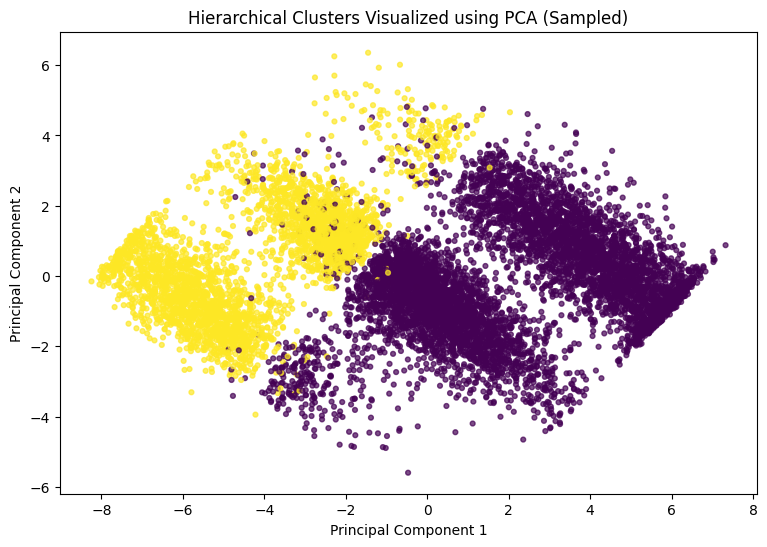

In [23]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Re-compute PCA if X_pca is not present
try:
    _ = X_pca
except NameError:
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))

# Only plot the sampled points to match our clustering results
plt.scatter(
    X_pca[hier_sample_mask, 0],
    X_pca[hier_sample_mask, 1],
    c=hierarchical_labels[hier_sample_mask],
    s=12,
    alpha=0.7
)

plt.title("Hierarchical Clusters Visualized using PCA (Sampled)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# 3. DBSCAN

DBSCAN groups points based on density.

Important parameters:

- `eps` — neighborhood radius
- `min_samples` — minimum number of points needed to form a dense region

DBSCAN can identify noise points as cluster `-1`.

### Choosing DBSCAN `eps`

The k-distance graph helps identify a reasonable neighborhood radius.

The value below uses the 5th nearest neighbor distance because it is a practical starting point for this dataset.

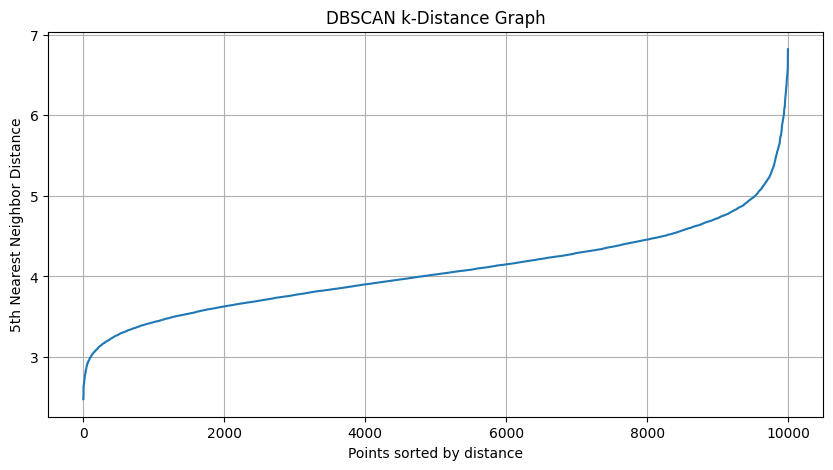

In [24]:
from sklearn.neighbors import NearestNeighbors

# Initialize local random state to avoid NameError: name 'rng' is not defined
rng = np.random.RandomState(42)

# Use a sample for the k-distance plot if the dataset is large
dbscan_sample_size = min(10000, len(X_scaled))
dbscan_indices = rng.choice(
    len(X_scaled),
    size=dbscan_sample_size,
    replace=False
)

X_db_sample = X_scaled[dbscan_indices]

min_samples_db = 5

neighbors = NearestNeighbors(
    n_neighbors=min_samples_db
)

neighbors.fit(X_db_sample)

distances, _ = neighbors.kneighbors(X_db_sample)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.title("DBSCAN k-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples_db}th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

### DBSCAN

The `eps` value below is a starting value. If your k-distance graph suggests a different elbow, change `eps` accordingly.

In [25]:
from sklearn.cluster import DBSCAN

# DBSCAN clustering with updated parameters based on the k-distance graph
eps_value = 4.0
min_samples_value = 5

dbscan_model = DBSCAN(
    eps=eps_value,
    min_samples=min_samples_value
)

dbscan_labels = dbscan_model.fit_predict(X_scaled)

print("DBSCAN completed!")

unique_labels = np.unique(dbscan_labels)

print("Labels found:", unique_labels)

cluster_counts = pd.Series(
    dbscan_labels
).value_counts().sort_index()

print("\nCluster counts:")
print(cluster_counts)

DBSCAN completed!
Labels found: [-1  0  1  2  3  4  5  6  7]

Cluster counts:
-1     2217
 0    41842
 1     3153
 2     2745
 3        5
 4        9
 5       18
 6        6
 7        5
Name: count, dtype: int64


In [26]:
# DBSCAN silhouette score is calculated only when there are
# at least two non-noise clusters.

non_noise_mask = dbscan_labels != -1
non_noise_labels = dbscan_labels[non_noise_mask]

if (
    len(np.unique(non_noise_labels)) >= 2
    and len(non_noise_labels) > 1
):
    dbscan_silhouette = silhouette_score(
        X_scaled[non_noise_mask],
        non_noise_labels
    )
    print(
        "DBSCAN Silhouette Score (excluding noise):",
        round(dbscan_silhouette, 4)
    )
else:
    dbscan_silhouette = np.nan
    print(
        "Silhouette score cannot be calculated because "
        "DBSCAN produced fewer than two non-noise clusters."
    )

DBSCAN Silhouette Score (excluding noise): -0.0388


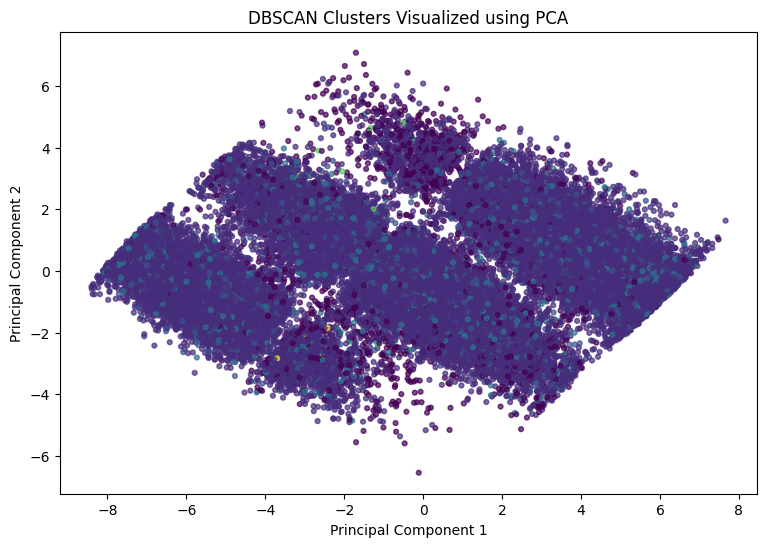

In [27]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    s=12,
    alpha=0.7
)

plt.title("DBSCAN Clusters Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Compare the Three Clustering Algorithms

In [28]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

# Ensure kmeans_labels exist in the session
try:
    _ = kmeans_labels
except NameError:
    print("Re-running K-Means to restore missing labels in the current session...")
    kmeans_model = KMeans(n_clusters=2, random_state=42, n_init=10)
    kmeans_labels = kmeans_model.fit_predict(X_scaled)

# Ensure kmeans_silhouette is calculated if lost from active session
try:
    _ = kmeans_silhouette
except NameError:
    # Use a sample of 10,000 for fast silhouette calculation
    sil_sample_size = min(10000, len(X_scaled))
    rng_sil = np.random.RandomState(42)
    sil_indices = rng_sil.choice(len(X_scaled), size=sil_sample_size, replace=False)
    kmeans_silhouette = silhouette_score(X_scaled[sil_indices], kmeans_labels[sil_indices])

comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette,
        dbscan_silhouette
    ]
})

display(comparison)

,Algorithm,Silhouette Score
0,K-Means,0.191449
1,Hierarchical,0.184781
2,DBSCAN,-0.038812


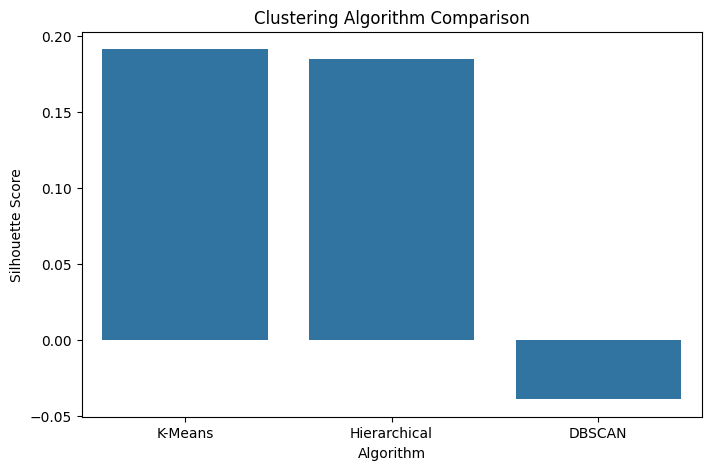

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Algorithm",
    y="Silhouette Score"
)

plt.title("Clustering Algorithm Comparison")
plt.ylabel("Silhouette Score")
plt.xlabel("Algorithm")
plt.show()

In [30]:
clustered_df = df.copy()
clustered_df["KMeans_Cluster"] = kmeans_labels

print("K-Means cluster profile:")
display(
    clustered_df.groupby("KMeans_Cluster").mean(
        numeric_only=True
    ).round(2)
)

K-Means cluster profile:


,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly,Salary Package
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,24982.95,8.14,8.17,8.20,8.23,8.26,8.29,8.31,8.34,8.24,...,2.50,1.02,76.06,3.61,68.02,64.67,0.63,0.95,0.03,14.9
1,25027.44,5.78,5.77,5.75,5.74,5.73,5.72,5.70,5.69,5.73,...,1.06,0.30,57.77,2.45,41.17,41.15,0.38,0.21,0.04,1.3


In [31]:
print("Number of students in each K-Means cluster:")
display(
    clustered_df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Student Count")
)

Number of students in each K-Means cluster:


,Student Count
KMeans_Cluster,
0,30278
1,19722


In [32]:
print("========== FINAL CLUSTERING SUMMARY ==========")
print(f"K-Means Silhouette Score     : {kmeans_silhouette:.4f}")
print(f"Hierarchical Silhouette Score: {hierarchical_silhouette:.4f}")

if pd.notna(dbscan_silhouette):
    print(f"DBSCAN Silhouette Score       : {dbscan_silhouette:.4f}")
else:
    print("DBSCAN Silhouette Score       : Not available")

best_algorithm = comparison.loc[
    comparison["Silhouette Score"].idxmax(),
    "Algorithm"
]

print("\nBest algorithm based on available silhouette score:", best_algorithm)
print("==============================================")

========== FINAL CLUSTERING SUMMARY ==========
K-Means Silhouette Score     : 0.1914
Hierarchical Silhouette Score: 0.1848
DBSCAN Silhouette Score       : -0.0388

Best algorithm based on available silhouette score: K-Means
